<a href="https://colab.research.google.com/github/vikobaldigi/DATA-71200-Advanced-Data-Analysis-Methods-Project/blob/main/KovacevicVi_Project1_Data_Preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1: Data Preparation and Exploratory Analysis

**Student:** Vi Kovacevic  
**Course:** DATA 71200 - Advanced Data Analytics  
**Date:** November 2024

---

## Dataset Description

This project uses the **NYC High School Performance Dataset** from NYC Open Data.

**Dataset Characteristics:**
- **Sample Size:** 410 unique NYC high schools
- **Features:** 29 variables capturing school characteristics
- **Target Variable:** Performance (Low, Medium, High) based on mean Regents exam scores

**Feature Categories:**
1. **School Staffing Metrics**
   - Teacher_Count: Total number of teachers
   - Student_Teacher_Ratio: Students per teacher
   - Leadership_Teacher_Ratio: Leadership staff per teacher

2. **Teacher Demographics and Experience**
   - Avg_Years_Title: Average years of teaching experience
   - Avg_Years_School: Average years at current school
   - Male_Teacher_Percentage: Percentage of male teachers
   - Female_Teacher_Percentage: Percentage of female teachers

3. **Student Demographics**
   - Asian_Percent: Percentage of Asian students
   - Black_Percent: Percentage of Black students
   - Hispanic_Percent: Percentage of Hispanic students
   - White_Percent: Percentage of White students

4. **Performance Metrics**
   - MeanScore: Average Regents exam score
   - Performance: Categorical classification (Low/Medium/High)

**Research Question:**  
Can we predict a high school's academic performance category based on its staffing characteristics, teacher demographics, and student demographics?

**Prediction Task:**  
This is a **supervised classification** problem with three target classes (Low, Medium, High). The dataset will be used for classification in Project 2 and clustering analysis in Project 3.

---

## Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix

# sklearn stuff for splitting data and handling missing values
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# so results are reproducible
np.random.seed(42)

# show all columns in dataframe outputs
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


## Load Dataset from GitHub

In [2]:
# Load data from my GitHub repo
url = 'https://raw.githubusercontent.com/vikobaldigi/DATA-71200-Advanced-Data-Analysis-Methods-Project/97cdf46403f97f12ebb92f538f41a136109f7bc3/data/schools_transformed.csv'

df = pd.read_csv(url)

print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns")
df.head()

Loaded 410 rows and 20 columns


,DBN,School_Name,Neighborhood,MeanScore,Leadership_Count,Teacher_Count,Other_Staff_Count,Total_Staff,Male_Teacher_Percentage,Female_Teacher_Percentage,Student_Teacher_Ratio,Leadership_Teacher_Ratio,Support_Staff_Ratio,Avg_Years_Title,Avg_Years_School,Asian_Percent,Black_Percent,Hispanic_Percent,White_Percent,Performance
0,02M260,THE CLINTON SCHOOL,Pelham - Throgs Neck,66.843889,3.0,56.0,11.0,70.0,23.214286,76.785714,1.292659,0.053571,0.157143,8.692857,4.587500,0.000000,16.718333,83.281667,0.000000,Medium
1,02M413,SCHOOL OF THE FUTURE HIGH SCHOOL,Bensonhurst - Bay Ridge,70.226190,4.0,51.0,17.0,72.0,43.137255,56.862745,14.581699,0.078431,0.236111,10.521569,7.860784,42.723810,1.451429,31.039524,24.786190,High
2,02M422,QUEST TO LEARN,Chelsea - Clinton,66.642111,3.0,51.0,16.0,70.0,35.294118,64.705882,1.743945,0.058824,0.228571,9.317647,4.870588,5.597647,27.857647,51.262353,15.282353,Medium
3,02M546,ACADEMY FOR SOFTWARE ENGINEERING,Union Square - Lower East Side,69.660333,3.0,32.0,13.0,48.0,46.875000,53.125000,3.556641,0.093750,0.270833,6.937500,4.206250,8.689375,25.928125,59.697500,5.684375,High
4,03M860,FREDERICK DOUGLASS ACADEMY II SECONDARY SCHOOL,Bedford Stuyvesant - Crown Heights,62.231222,3.0,38.0,11.0,52.0,39.473684,60.526316,1.329721,0.078947,0.211538,5.571053,2.644737,0.000000,92.454706,7.545294,0.000000,Medium


---

# Step 2: Divide into Training and Testing Sets

Using scikit-learn's `train_test_split` with stratification to ensure balanced target classes in both sets.

In [3]:
# Check the target variable before splitting
print("Performance levels in full dataset:")
print(df['Performance'].value_counts().sort_index())
print("\nAs percentages:")
print(df['Performance'].value_counts(normalize=True).sort_index())

Performance levels in full dataset:
Performance
High      137
Low       137
Medium    136
Name: count, dtype: int64

As percentages:
Performance
High      0.334146
Low       0.334146
Medium    0.331707
Name: proportion, dtype: float64


In [4]:
# Split into 80% training and 20% test
# stratify keeps the same proportion of Low/Medium/High in both sets
train_set, test_set = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['Performance']
)

print(f"Training set: {len(train_set)} schools")
print(f"Test set: {len(test_set)} schools")

Training set: 328 schools
Test set: 82 schools


In [5]:
# Make sure the classes stayed balanced after splitting
print("Training set breakdown:")
print(train_set['Performance'].value_counts().sort_index())
print("\nAs percentages:")
print(train_set['Performance'].value_counts(normalize=True).sort_index())

print("\n" + "="*60)
print("Test set breakdown:")
print(test_set['Performance'].value_counts().sort_index())
print("\nAs percentages:")
print(test_set['Performance'].value_counts(normalize=True).sort_index())

# Check how different the proportions are
train_props = train_set['Performance'].value_counts(normalize=True).sort_index()
test_props = test_set['Performance'].value_counts(normalize=True).sort_index()
max_diff = abs(train_props - test_props).max()

print(f"\nBiggest difference between train/test: {max_diff:.4f}")
if max_diff < 0.02:
    print("Good - classes are well balanced between sets")

Training set breakdown:
Performance
High      109
Low       110
Medium    109
Name: count, dtype: int64

As percentages:
Performance
High      0.332317
Low       0.335366
Medium    0.332317
Name: proportion, dtype: float64

Test set breakdown:
Performance
High      28
Low       27
Medium    27
Name: count, dtype: int64

As percentages:
Performance
High      0.341463
Low       0.329268
Medium    0.329268
Name: proportion, dtype: float64

Biggest difference between train/test: 0.0091
Good - classes are well balanced between sets


---

# Step 3: Explore the Training Set

Using pandas functions to examine the structure and statistics of the training data.

In [6]:
# Look at what types of data we have
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 328 entries, 92 to 368
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   DBN                        328 non-null    object 
 1   School_Name                328 non-null    object 
 2   Neighborhood               328 non-null    object 
 3   MeanScore                  328 non-null    float64
 4   Leadership_Count           328 non-null    float64
 5   Teacher_Count              328 non-null    float64
 6   Other_Staff_Count          328 non-null    float64
 7   Total_Staff                328 non-null    float64
 8   Male_Teacher_Percentage    314 non-null    float64
 9   Female_Teacher_Percentage  314 non-null    float64
 10  Student_Teacher_Ratio      328 non-null    float64
 11  Leadership_Teacher_Ratio   328 non-null    float64
 12  Support_Staff_Ratio        328 non-null    float64
 13  Avg_Years_Title            328 non-null    float64
 14

In [7]:
# Get summary stats for numeric columns
train_set.describe()

,MeanScore,Leadership_Count,Teacher_Count,Other_Staff_Count,Total_Staff,Male_Teacher_Percentage,Female_Teacher_Percentage,Student_Teacher_Ratio,Leadership_Teacher_Ratio,Support_Staff_Ratio,Avg_Years_Title,Avg_Years_School,Asian_Percent,Black_Percent,Hispanic_Percent,White_Percent
count,328.000000,328.000000,328.000000,328.000000,328.000000,314.000000,314.000000,328.000000,328.000000,328.000000,328.000000,328.000000,328.000000,328.000000,328.000000,328.000000
mean,65.491714,3.829268,45.362805,12.814024,62.006098,41.103733,58.896267,3.505047,0.100217,0.201927,10.207394,6.318659,8.236891,33.529989,51.974319,6.258797
std,7.337634,2.734108,43.792387,15.108947,60.018346,9.458232,9.458232,1.680084,0.040822,0.051937,3.551253,2.588857,14.907256,26.884957,27.111740,12.644561
min,43.164333,1.000000,5.000000,2.000000,8.000000,14.705882,33.333333,0.741880,0.022222,0.090909,0.000000,0.000000,0.000000,0.000000,0.820625,0.000000
25%,60.569861,2.000000,24.000000,6.000000,33.000000,35.052817,52.941176,2.668925,0.075933,0.166667,8.372721,4.755672,0.000000,14.332639,28.243077,0.000000
50%,63.761000,3.000000,32.000000,9.000000,44.000000,40.682870,59.317130,3.248958,0.093750,0.196078,10.542602,6.438158,1.421053,26.636528,57.720441,0.519514
75%,69.313750,4.000000,46.000000,13.000000,60.000000,47.058824,64.947183,4.037031,0.117647,0.232929,12.547794,7.944167,9.425347,42.704608,73.417917,5.029284
max,92.898000,15.000000,288.000000,130.000000,373.000000,66.666667,85.294118,19.164706,0.333333,0.394495,19.470588,12.948062,98.936429,98.828125,100.000000,74.136000


In [8]:
# Check what categorical columns we have
categorical_cols = train_set.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"{col}: {train_set[col].nunique()} unique values")
    print(f"  {list(train_set[col].unique()[:5])}")
    print()

DBN: 328 unique values
  ['71M533', '71M047', '76K429', '72X530', '72X478']

School_Name: 328 unique values
  ['UNION SQUARE ACADEMY FOR HEALTH SCIENCES', '47 THE AMERICAN SIGN LANGUAGE AND ENGLISH SECONDAR', 'DIGITAL ARTS AND CINEMA TECHNOLOGY HIGH SCHOOL', 'LONGWOOD PREPARATORY ACADEMY', 'THE CINEMA SCHOOL']

Neighborhood: 43 unique values
  ['Union Square - Lower East Side', 'Gramercy Park - Murray Hill', 'Downtown - Heights - Park Slope', 'Hunts Point - Mott Haven', 'Pelham - Throgs Neck']

Performance: 3 unique values
  ['Medium', 'High', 'Low']



In [9]:
# Count numeric vs categorical columns
print(f"Numeric columns: {len(train_set.select_dtypes(include=[np.number]).columns)}")
print(f"Categorical columns: {len(train_set.select_dtypes(include=['object']).columns)}")

Numeric columns: 16
Categorical columns: 4


---

# Step 4: Data Cleaning

Addressing missing values using scikit-learn's SimpleImputer.

In [10]:
# Check for missing values
missing_train = train_set.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)

if len(missing_train) > 0:
    print("Columns with missing values:")
    for col, count in missing_train.items():
        pct = 100 * count / len(train_set)
        print(f"  {col}: {count} missing ({pct:.1f}%)")
else:
    print("No missing values")

Columns with missing values:
  Male_Teacher_Percentage: 14 missing (4.3%)
  Female_Teacher_Percentage: 14 missing (4.3%)


In [11]:
# Fill in missing values using median (it's more robust than mean)
if len(missing_train) > 0:
    numeric_cols = train_set.select_dtypes(include=[np.number]).columns.tolist()

    imputer = SimpleImputer(strategy='median')
    train_set_numeric = train_set[numeric_cols]
    train_set_imputed = imputer.fit_transform(train_set_numeric)

    train_set_cleaned = train_set.copy()
    train_set_cleaned[numeric_cols] = train_set_imputed

    print(f"Filled {len([col for col in numeric_cols if col in missing_train.index])} columns using median")
    print(f"Missing values remaining: {train_set_cleaned.isnull().sum().sum()}")
else:
    train_set_cleaned = train_set.copy()
    imputer = None
    print("No missing values to fix")

Filled 2 columns using median
Missing values remaining: 0


In [12]:
# Apply same fix to test set (important: use the same imputer from training!)
missing_test = test_set.isnull().sum()
missing_test = missing_test[missing_test > 0]

if len(missing_test) > 0:
    print("Missing in test set:")
    for col, count in missing_test.items():
        print(f"  {col}: {count}")

if imputer is not None and len(missing_test) > 0:
    test_set_numeric = test_set[numeric_cols]
    test_set_imputed = imputer.transform(test_set_numeric)  # don't fit again!

    test_set_cleaned = test_set.copy()
    test_set_cleaned[numeric_cols] = test_set_imputed
    print("Applied same imputation to test set")
else:
    test_set_cleaned = test_set.copy()
    print("Test set is good")

Missing in test set:
  Male_Teacher_Percentage: 5
  Female_Teacher_Percentage: 5
Applied same imputation to test set


In [13]:
# Quick check that both sets are ready
print(f"Train: {train_set_cleaned.shape}, Missing: {train_set_cleaned.isnull().sum().sum()}")
print(f"Test: {test_set_cleaned.shape}, Missing: {test_set_cleaned.isnull().sum().sum()}")

Train: (328, 20), Missing: 0
Test: (82, 20), Missing: 0


---

# Step 5: Visualize the Training Set

Using DataFrame.hist() and scatter_matrix() to visualize data distributions and relationships.

## 5a: Histograms (DataFrame.hist())

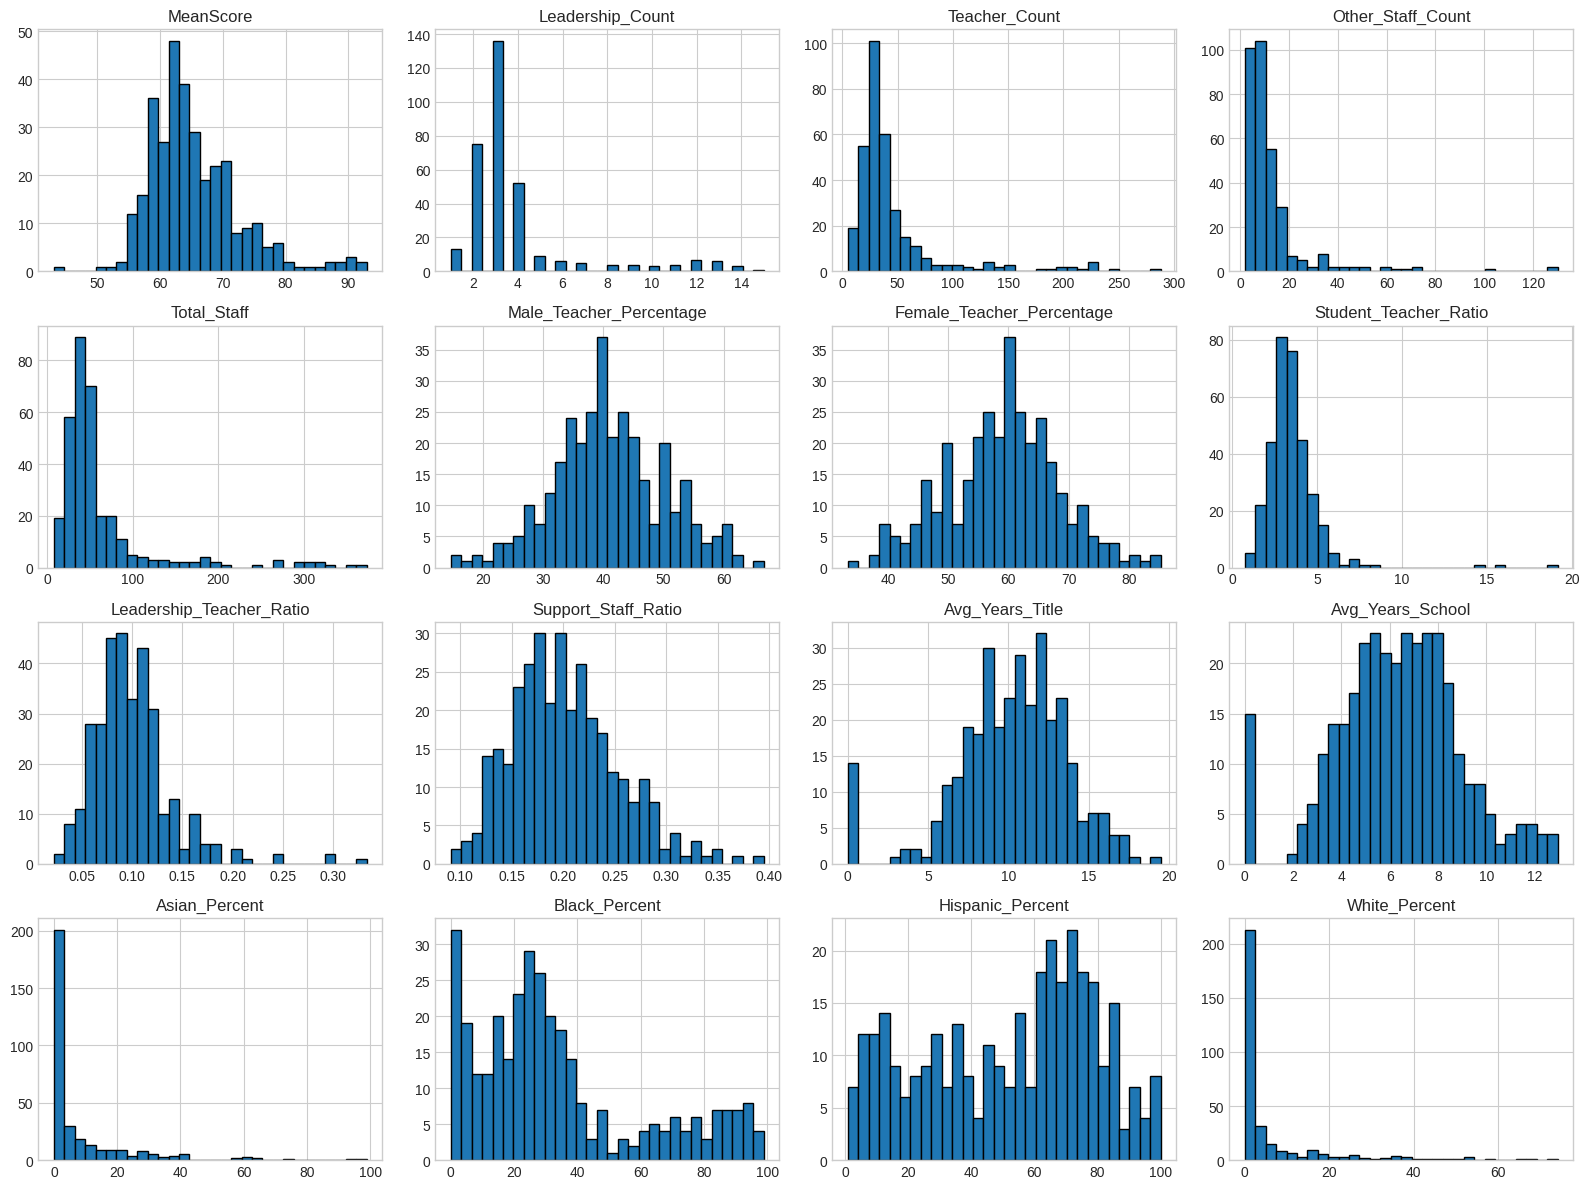

In [14]:
# Make histograms for all numeric columns
numeric_features = train_set_cleaned.select_dtypes(include=[np.number]).columns

train_set_cleaned[numeric_features].hist(
    bins=30,
    figsize=(16, 12),
    edgecolor='black'
)
plt.tight_layout()
plt.show()

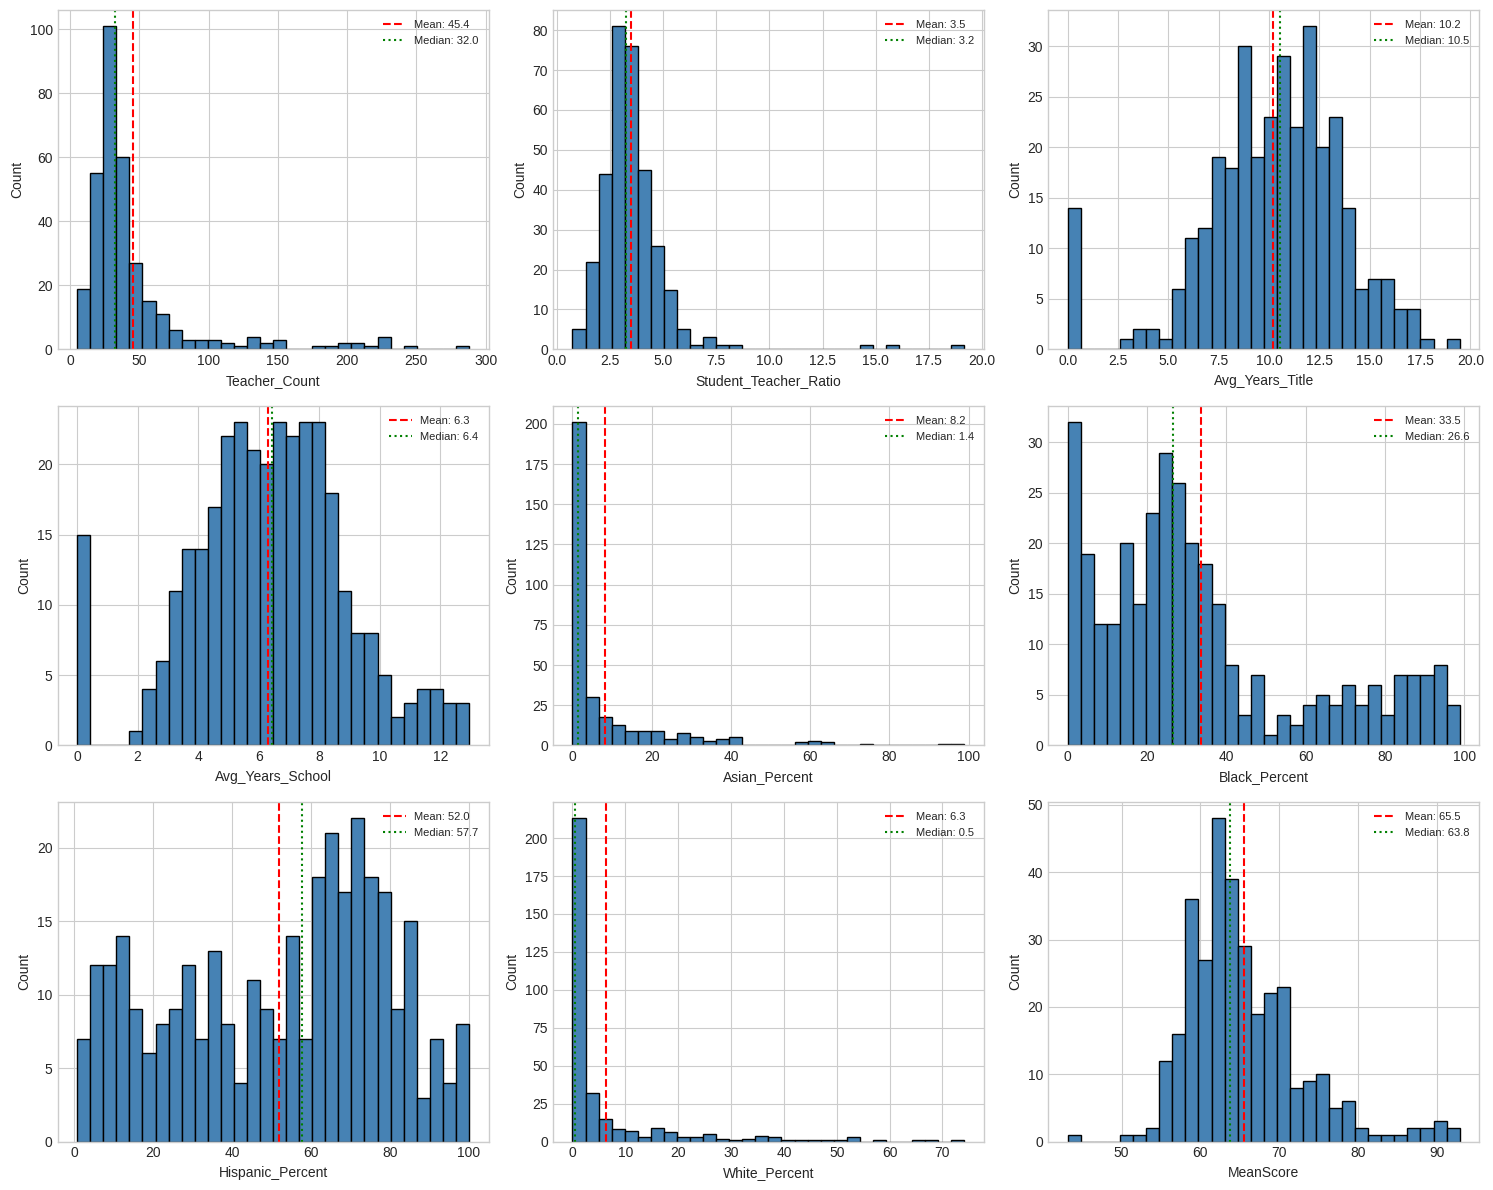

In [15]:
# Closer look at some key features
key_features = [
    'Teacher_Count', 'Student_Teacher_Ratio', 'Avg_Years_Title',
    'Avg_Years_School', 'Asian_Percent', 'Black_Percent',
    'Hispanic_Percent', 'White_Percent', 'MeanScore'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, feature in enumerate(key_features):
    axes[i].hist(train_set_cleaned[feature], bins=30, edgecolor='black', color='steelblue')

    # add mean and median lines
    mean_val = train_set_cleaned[feature].mean()
    median_val = train_set_cleaned[feature].median()
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
    axes[i].axvline(median_val, color='green', linestyle=':', label=f'Median: {median_val:.1f}')

    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5b: Scatter Matrix (plotting.scatter_matrix())

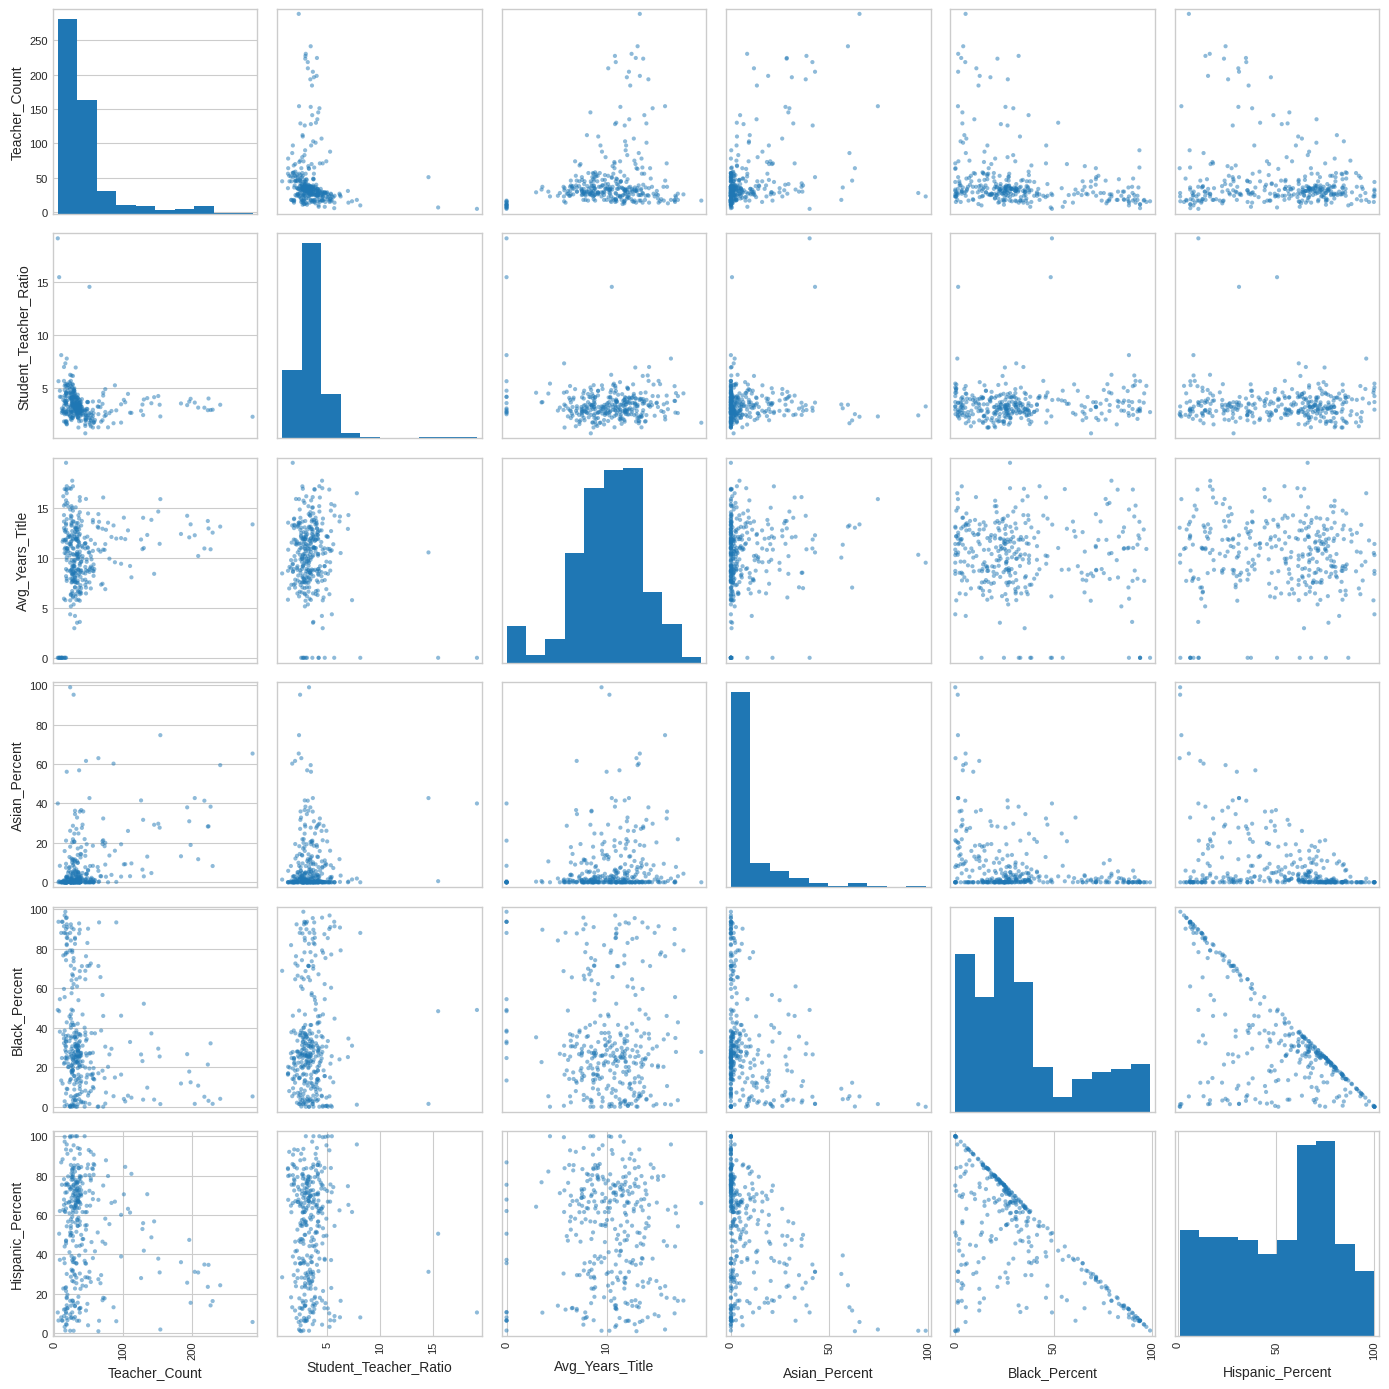

In [16]:
# Scatter matrix to see how features relate to each other
scatter_features = [
    'Teacher_Count', 'Student_Teacher_Ratio', 'Avg_Years_Title',
    'Asian_Percent', 'Black_Percent', 'Hispanic_Percent'
]

scatter_matrix(
    train_set_cleaned[scatter_features],
    figsize=(14, 14),
    diagonal='hist',
    alpha=0.5
)
plt.tight_layout()
plt.show()

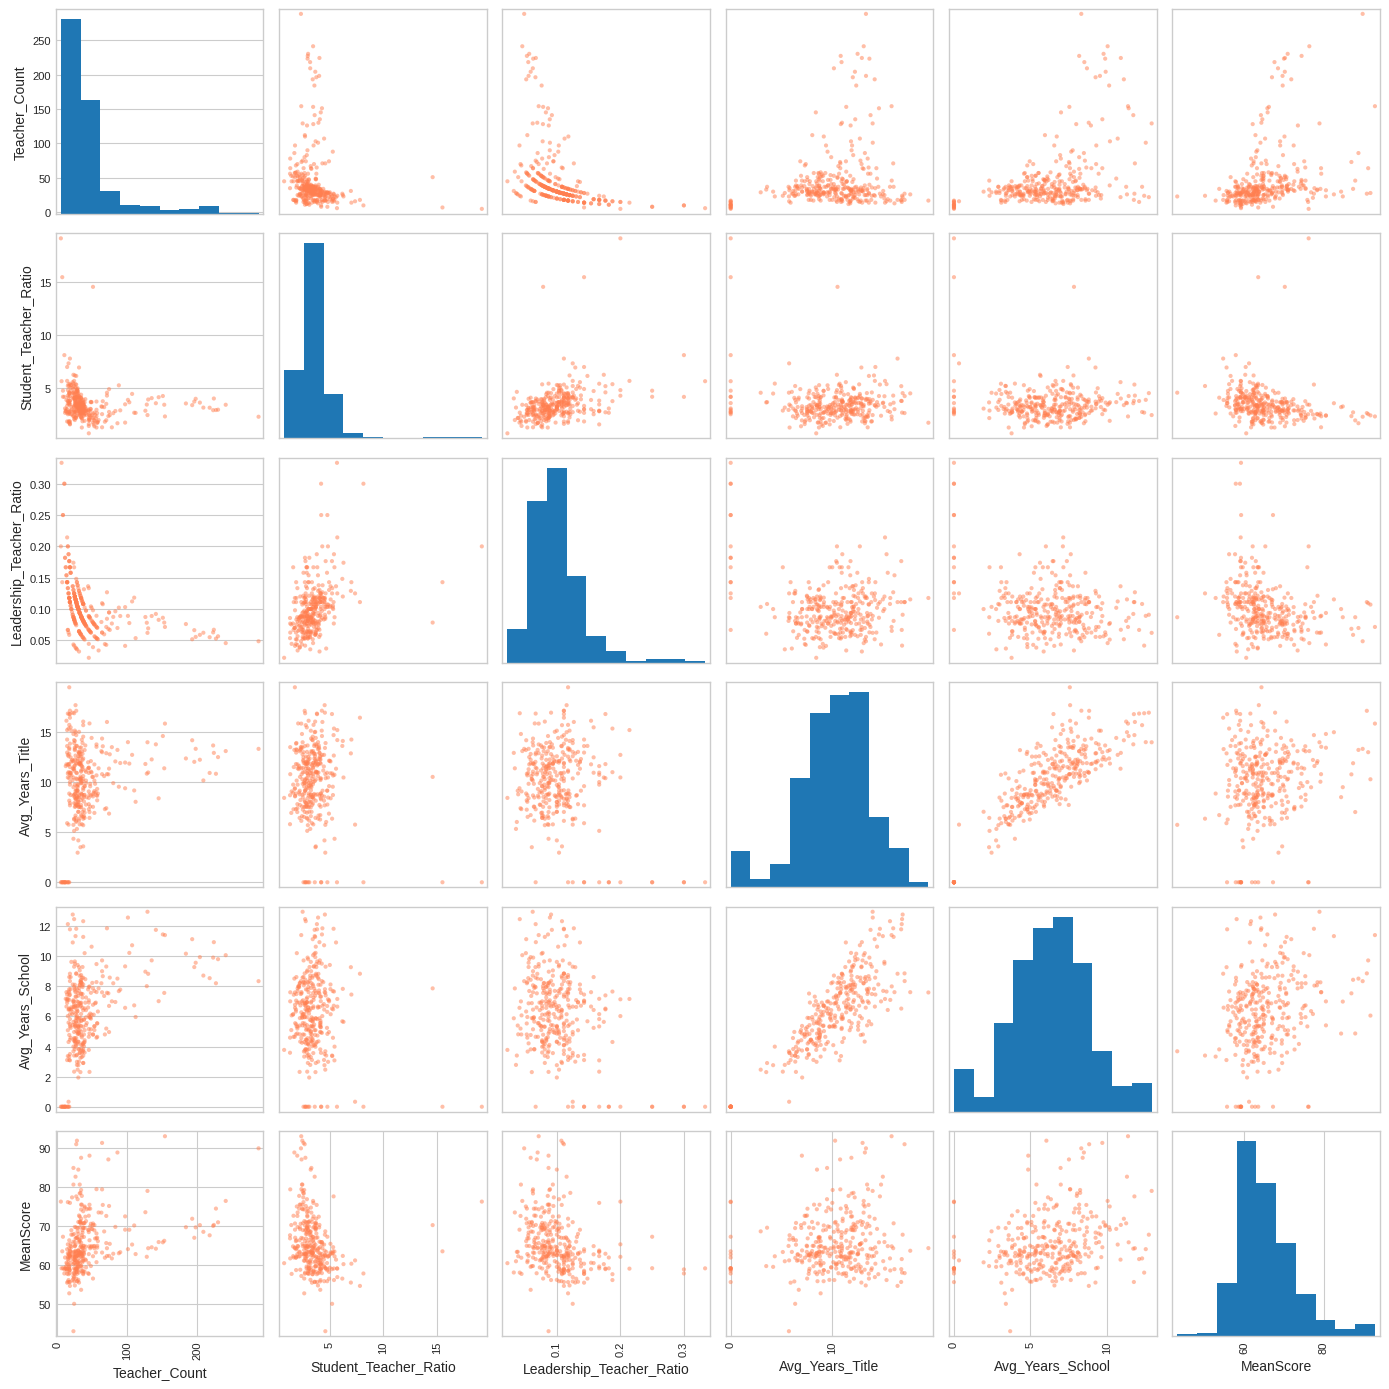

In [17]:
# Another scatter matrix focusing on staffing metrics
performance_features = [
    'Teacher_Count', 'Student_Teacher_Ratio', 'Leadership_Teacher_Ratio',
    'Avg_Years_Title', 'Avg_Years_School', 'MeanScore'
]

scatter_matrix(
    train_set_cleaned[performance_features],
    figsize=(14, 14),
    diagonal='hist',
    alpha=0.5,
    color='coral'
)
plt.tight_layout()
plt.show()

---

# Step 6: Apply Transformations

Applying mathematical transformations (squared, cubed, logarithmic, exponential) to selected features.

In [18]:
# Pick two features to transform
feature_1 = 'Teacher_Count'
feature_2 = 'Avg_Years_Title'

print(f"Transforming: {feature_1} and {feature_2}")

Transforming: Teacher_Count and Avg_Years_Title


In [19]:
# Transform Teacher_Count
original_1 = train_set_cleaned[feature_1].copy()

squared_1 = original_1 ** 2
cubed_1 = original_1 ** 3
log_1 = np.log(original_1 + 1)  # add 1 to avoid log(0)
exp_1 = np.exp(original_1 / original_1.max())  # scale down to avoid overflow

print(f"Original {feature_1}:")
print(f"  Mean: {original_1.mean():.1f}")
print(f"  Range: {original_1.min():.1f} to {original_1.max():.1f}")

Original Teacher_Count:
  Mean: 45.4
  Range: 5.0 to 288.0


In [20]:
# Transform Avg_Years_Title
original_2 = train_set_cleaned[feature_2].copy()

squared_2 = original_2 ** 2
cubed_2 = original_2 ** 3
log_2 = np.log(original_2 + 1)
exp_2 = np.exp(original_2 / original_2.max())

print(f"Original {feature_2}:")
print(f"  Mean: {original_2.mean():.1f}")
print(f"  Range: {original_2.min():.1f} to {original_2.max():.1f}")

Original Avg_Years_Title:
  Mean: 10.2
  Range: 0.0 to 19.5


## Histograms of Transformed Features

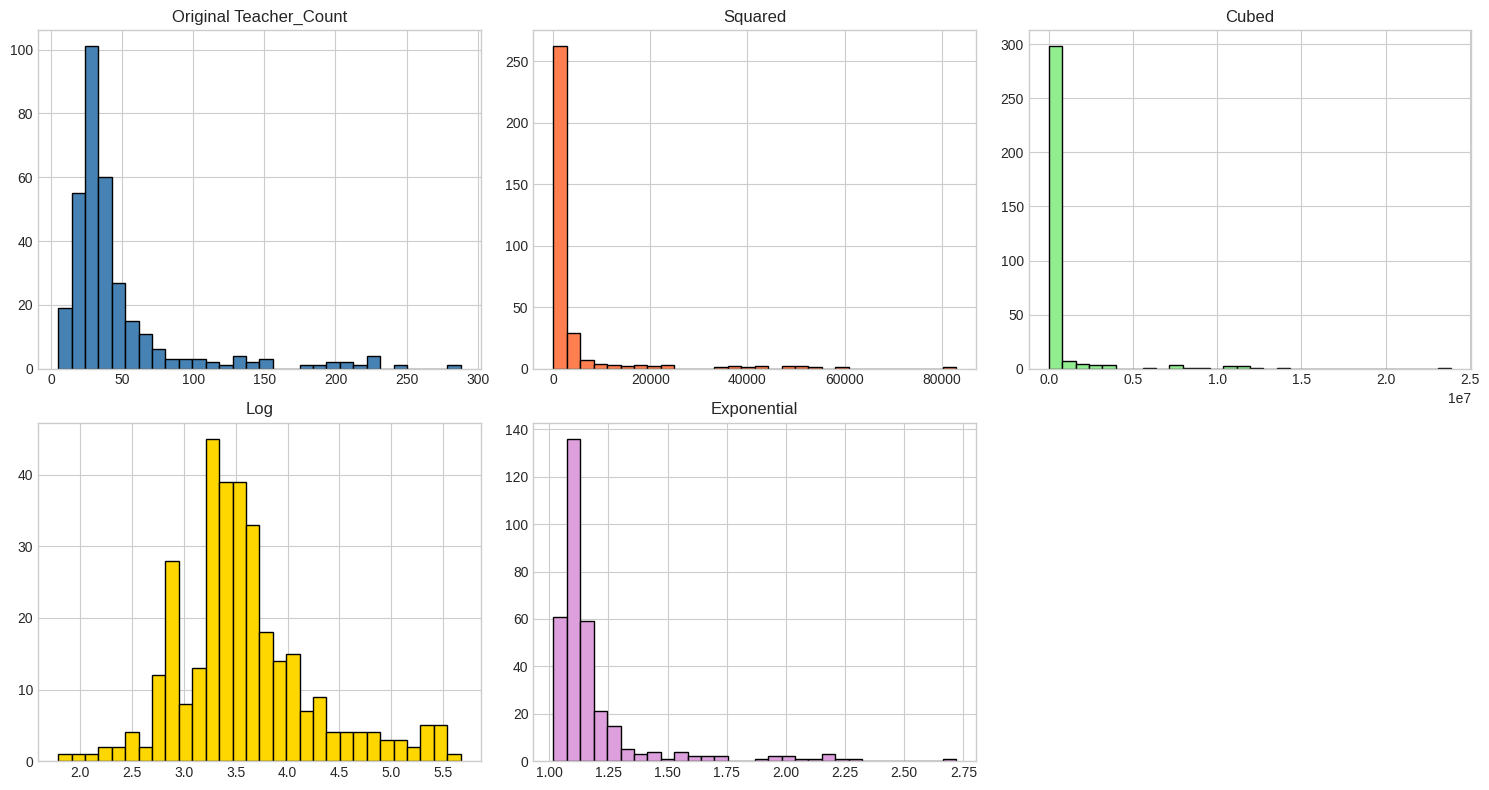

In [21]:
# Plot original and transformed Teacher_Count
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].hist(original_1, bins=30, edgecolor='black', color='steelblue')
axes[0, 0].set_title(f'Original {feature_1}')

axes[0, 1].hist(squared_1, bins=30, edgecolor='black', color='coral')
axes[0, 1].set_title('Squared')

axes[0, 2].hist(cubed_1, bins=30, edgecolor='black', color='lightgreen')
axes[0, 2].set_title('Cubed')

axes[1, 0].hist(log_1, bins=30, edgecolor='black', color='gold')
axes[1, 0].set_title('Log')

axes[1, 1].hist(exp_1, bins=30, edgecolor='black', color='plum')
axes[1, 1].set_title('Exponential')

axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

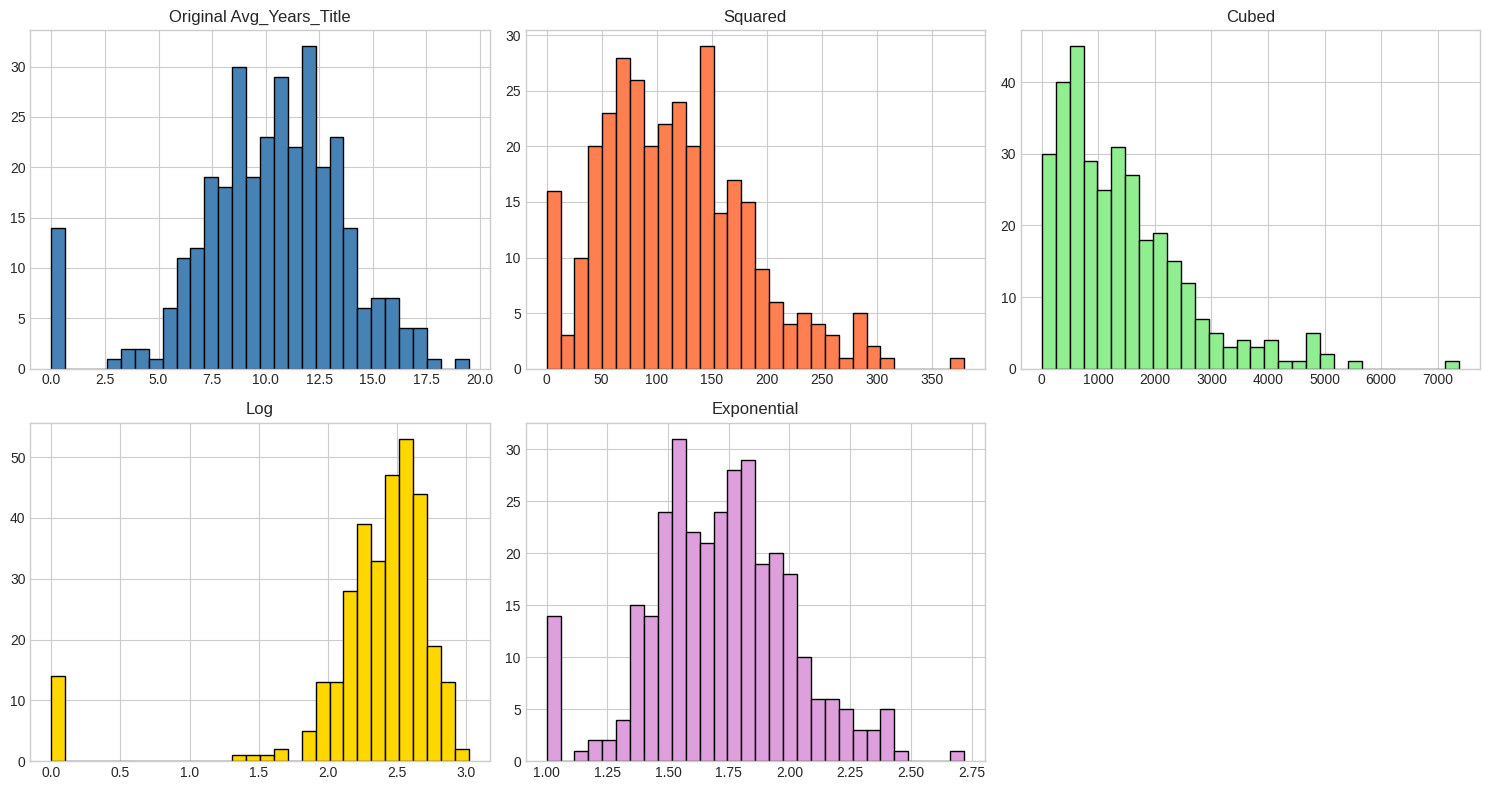

In [22]:
# Plot original and transformed Avg_Years_Title
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].hist(original_2, bins=30, edgecolor='black', color='steelblue')
axes[0, 0].set_title(f'Original {feature_2}')

axes[0, 1].hist(squared_2, bins=30, edgecolor='black', color='coral')
axes[0, 1].set_title('Squared')

axes[0, 2].hist(cubed_2, bins=30, edgecolor='black', color='lightgreen')
axes[0, 2].set_title('Cubed')

axes[1, 0].hist(log_2, bins=30, edgecolor='black', color='gold')
axes[1, 0].set_title('Log')

axes[1, 1].hist(exp_2, bins=30, edgecolor='black', color='plum')
axes[1, 1].set_title('Exponential')

axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

## Scatter Matrices of Transformed Features

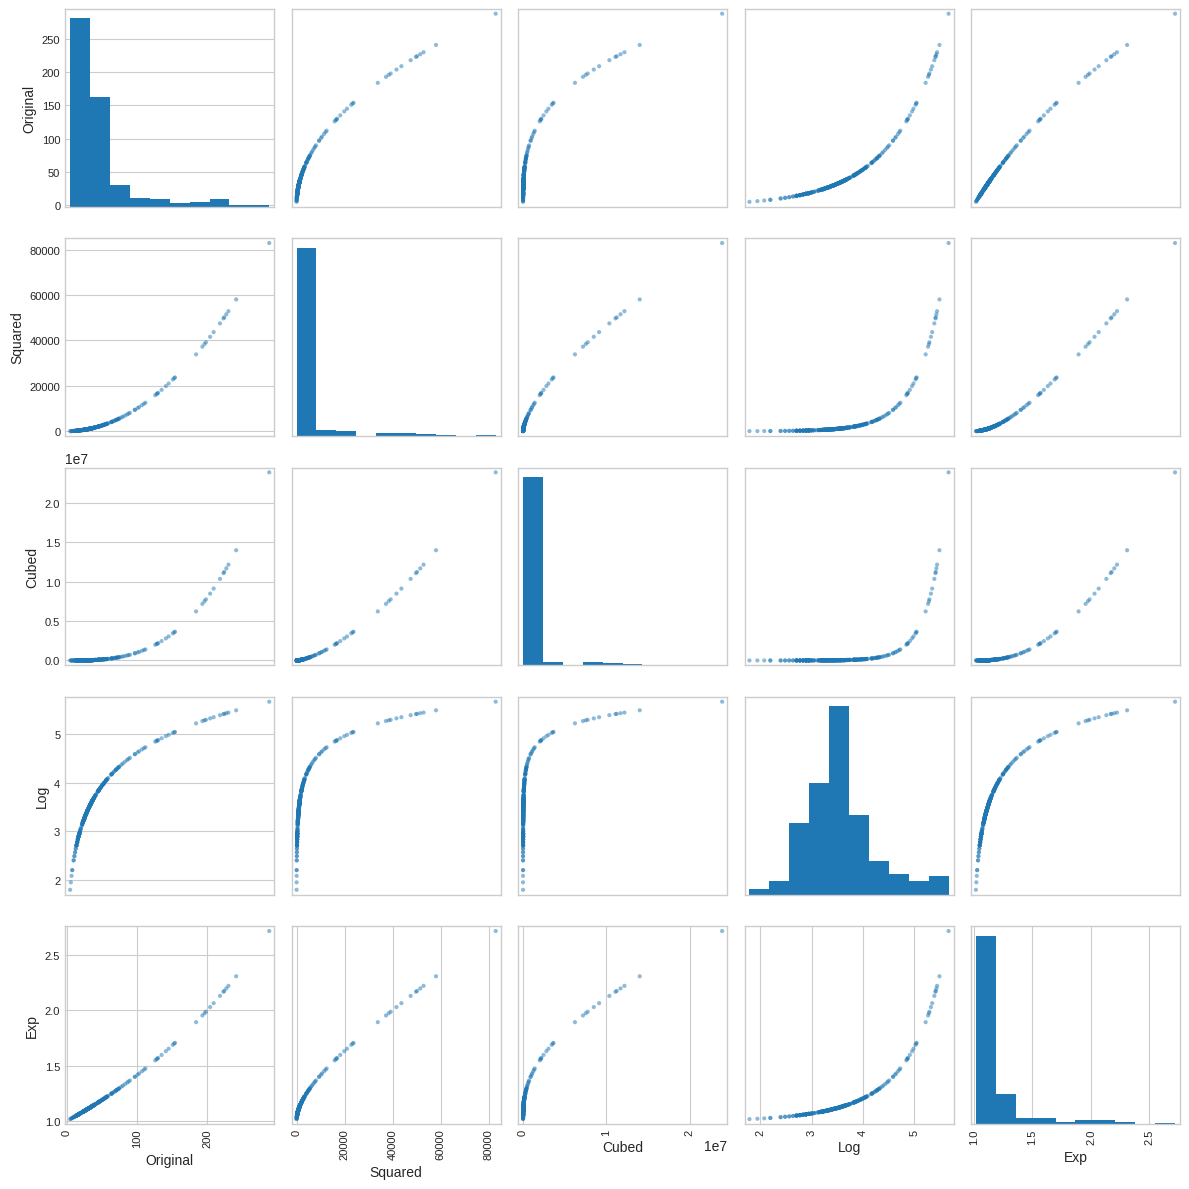

In [23]:
# Scatter matrix for Teacher_Count transformations
feature1_transformed = pd.DataFrame({
    'Original': original_1,
    'Squared': squared_1,
    'Cubed': cubed_1,
    'Log': log_1,
    'Exp': exp_1
})

scatter_matrix(feature1_transformed, figsize=(12, 12), diagonal='hist', alpha=0.5)
plt.tight_layout()
plt.show()

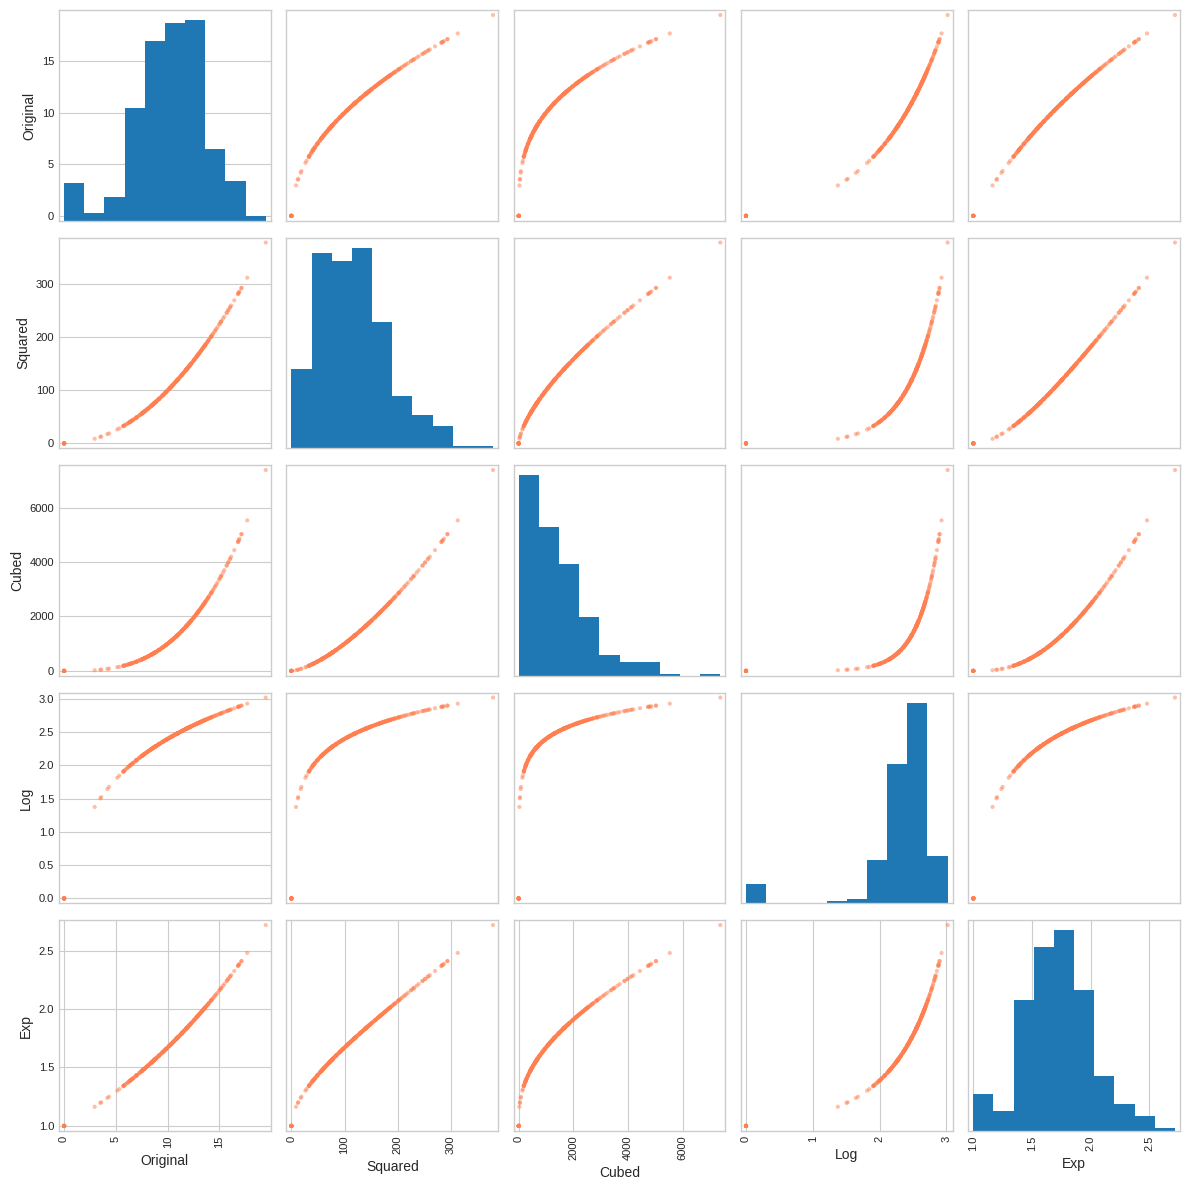

In [24]:
# Scatter matrix for Avg_Years_Title transformations
feature2_transformed = pd.DataFrame({
    'Original': original_2,
    'Squared': squared_2,
    'Cubed': cubed_2,
    'Log': log_2,
    'Exp': exp_2
})

scatter_matrix(feature2_transformed, figsize=(12, 12), diagonal='hist', alpha=0.5, color='coral')
plt.tight_layout()
plt.show()

In [25]:
# Quick stats on the transformations
print("Teacher_Count transformations:")
print(feature1_transformed.describe())

print("\nAvg_Years_Title transformations:")
print(feature2_transformed.describe())

Teacher_Count transformations:
         Original       Squared         Cubed         Log         Exp
count  328.000000    328.000000  3.280000e+02  328.000000  328.000000
mean    45.362805   3969.710366  5.970584e+05    3.582424    1.186427
std     43.792387  10015.489243  2.311446e+06    0.651471    0.228775
min      5.000000     25.000000  1.250000e+02    1.791759    1.017513
25%     24.000000    576.000000  1.382400e+04    3.218876    1.086904
50%     32.000000   1024.000000  3.276800e+04    3.496508    1.117519
75%     46.000000   2116.000000  9.733600e+04    3.850148    1.173185
max    288.000000  82944.000000  2.388787e+07    5.666427    2.718282

Avg_Years_Title transformations:
         Original     Squared        Cubed         Log         Exp
count  328.000000  328.000000   328.000000  328.000000  328.000000
mean    10.207394  116.763844  1416.432566    2.320050    1.716278
std      3.551253   66.673334  1152.526540    0.554596    0.297624
min      0.000000    0.000000     0.0

---

## Summary

This notebook completed all required data preparation steps:

**Step 2 - Train/Test Split:** Used stratified split (80/20) to maintain balanced classes. Training set has 328 schools, test set has 82 schools.

**Step 3 - Data Exploration:** Used `info()` and `describe()` to examine the data structure. Dataset has 10+ numeric features and 1 categorical target.

**Step 4 - Data Cleaning:** Found ~4.6% missing values. Used `SimpleImputer` with median strategy. Applied same imputation to test set.

**Step 5 - Visualization:** Created histograms with `hist()` and scatter matrices with `scatter_matrix()`. Looked at distributions and relationships between features.

**Step 6 - Transformations:** Applied squared, cubed, log, and exponential transformations to Teacher_Count and Avg_Years_Title. Created histograms and scatter matrices for all transformations.

**Key Observations:**
- Target variable (Performance) is perfectly balanced across 3 classes
- Most features are fairly clean with minimal missing data
- Log transformations help normalize skewed distributions
- Scatter matrices show some correlations between demographic features

**Ready for Projects 2 & 3:** Data is cleaned and ready for classification models and clustering analysis.